In [74]:
from torchvision import datasets
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.decomposition import PCA
import time

In [39]:
# 加载训练集和测试集
trainset = datasets.MNIST(root='./data', train=True, download=True)
testset  = datasets.MNIST(root='./data', train=False, download=True)
nTrain = trainset.data.shape[0]
trainData = trainset.data.numpy().reshape(nTrain, -1)
trainLabel = trainset.targets.numpy()
nTest = testset.data.shape[0]
testData = testset.data.numpy().reshape(nTest, -1)
testLabel = testset.targets.numpy()
print(f'nTrain:{nTrain} trainData:{trainData.shape} trainLabel:{trainLabel.shape}')
print(f'nTest:{nTest} testData:{testData.shape} testLabel:{testLabel.shape}')

nTrain:60000 trainData:(60000, 784) trainLabel:(60000,)
nTest:10000 testData:(10000, 784) testLabel:(10000,)


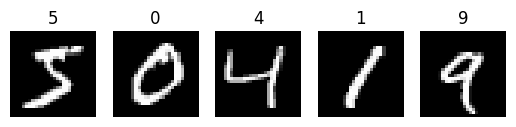

In [40]:
# 预览数据
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(trainData[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    plt.title(trainLabel[i])
plt.show()

In [41]:
# 数据预处理: 归一化至 [-1, 1]
trainData = (trainData / 255.0) * 2 - 1
testData = (testData / 255.0) * 2 - 1

In [77]:
class KNNClassifier:
    def __init__(self, parallel=False, nComponents=None):
        self.trainData = None
        self.trainLabel = None
        self.parallel = parallel
        self.nComponents = nComponents
        self.pca = None

    def fit(self, trainData, trainLabel):
        if self.nComponents is not None:
            self.pca = PCA(n_components=self.nComponents)
            self.trainData = self.pca.fit_transform(trainData)
        else:
            self.trainData = trainData
        self.trainLabel = trainLabel

    def _predict_single(self, data, k):
        distances = np.sqrt(np.sum((data - self.trainData) ** 2, axis=1))
        topk_indices = np.argsort(distances)[:k]
        topk_labels = self.trainLabel[topk_indices]
        result = Counter(topk_labels).most_common(1)[0][0]
        return result

    def predict(self, data, k=5):
        if data.ndim == 1:
            data = data.reshape(1, -1)
        if self.pca is not None:
            data = self.pca.transform(data)
        if self.parallel:
            results = Parallel(n_jobs=-1)(delayed(self._predict_single)(d, k) for d in data)
        else:
            results = [self._predict_single(d, k) for d in data]
        return np.array(results)

    def evaluate(self, data, groundtruth):
        nData = len(groundtruth)
        start = time.time()
        y_pred = self.predict(data)
        end = time.time()
        accuracy = np.sum(y_pred == groundtruth) / nData
        msPerData = (end - start) / nData * 1000
        print(f'the acuracy for {nData} testData is {100*accuracy:.2f}% ({msPerData:.2f} ms/data)')

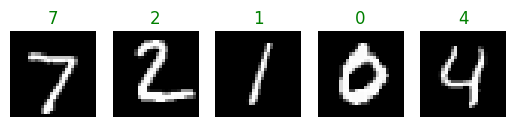

In [78]:
# 预览测试结果
knn = KNNClassifier()
knn.fit(trainData, trainLabel)
labelPredict = knn.predict(testData[:5])
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(testData[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    color = 'green'
    label = labelPredict[i]
    if label != testLabel[i]:
        color = 'red'
        label = "(" + label + ")"
    plt.title(label, color=color)
plt.show()

In [81]:
knn = KNNClassifier()
knn.fit(trainData, trainLabel)
knn.evaluate(testData[:100], testLabel[:100])

the acuracy for 100 testData is 99.00% (440.29 ms/data)


In [82]:
print('Parallel')
knn = KNNClassifier(parallel=True)
knn.fit(trainData, trainLabel)
knn.evaluate(testData[:100], testLabel[:100])

Parallel
the acuracy for 100 testData is 99.00% (245.68 ms/data)


In [90]:
print('Parallel+PCA')
knn = KNNClassifier(parallel=True, nComponents=100)
knn.fit(trainData, trainLabel)
knn.evaluate(testData[:100], testLabel[:100])

Parallel+PCA
the acuracy for 100 testData is 99.00% (27.75 ms/data)


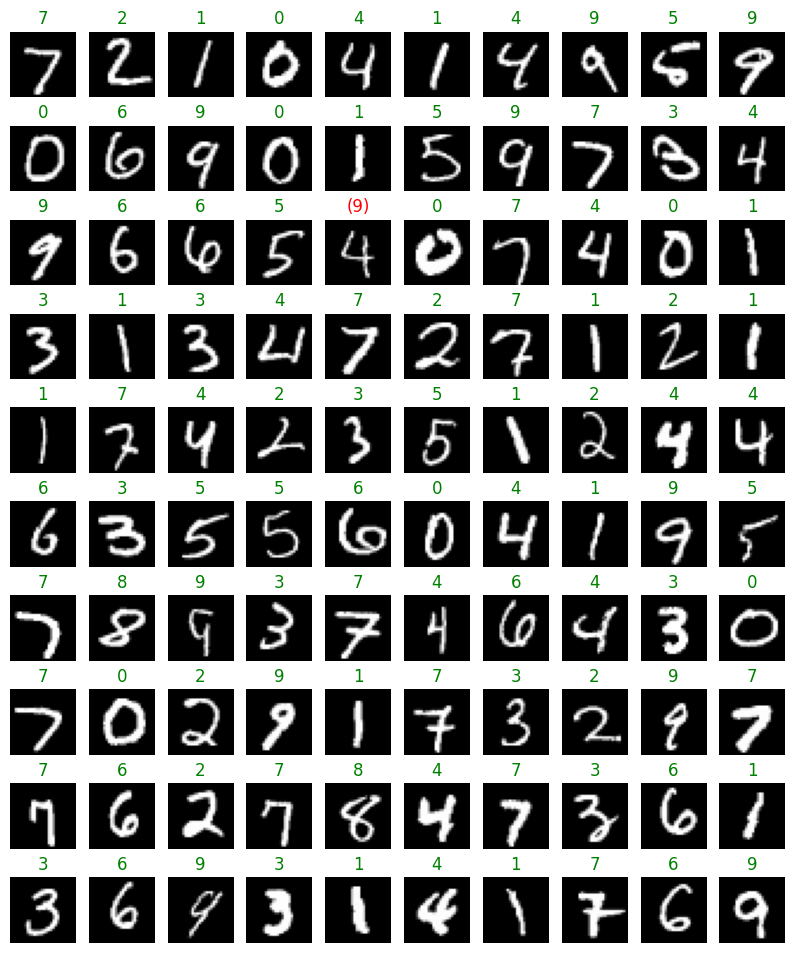

In [97]:
# 预览测试结果
knn = KNNClassifier(parallel=True, nComponents=100)
knn.fit(trainData, trainLabel)
labelPredict = knn.predict(testData[:100])
plt.figure(figsize=(10, 12)) 
for i in range(100):
    plt.subplot(10, 10, i+1)
    plt.imshow(testData[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
    color = 'green'
    label = str(labelPredict[i])
    if label != str(testLabel[i]):
        color = 'red'
        label = "(" + label + ")"
    plt.title(label, color=color)
plt.show()